# Day#3: Ray Tracing with PyTorch

> **Learning Log** | Chapter 0: Fundamentals  
> **Topics:** PyTorch tensors · Batched operations · Linear algebra · 3D rendering

---

## Overview

Week 1 uses **ray tracing** as a vehicle to build intuition for PyTorch tensor operations — batching, broadcasting, einops, and linear solves.

The progression:
```
1D ray-segment intersection
        ↓
Batched operations over many rays & segments
        ↓
Triangle parametrization & ray-triangle intersection
        ↓
Full 3D mesh rendering (412-triangle Pikachu)
        ↓
Lambertian lighting + GPU acceleration
```

> **Key insight:** This is less about graphics and more about thinking in tensors.

---

### Table of Contents
1. [What is Ray Tracing?](#section1)
2. [Section 1 — Rays & Segments](#section2)
3. [Section 2 — Batched Operations](#section3)
4. [Section 3 — Triangles & Mesh Rendering](#section4)
5. [Section 4 — Lighting & GPU (Bonus)](#section5)
6. [Views vs Copies](#section6)
7. [Math Summary](#section7)
8. [Key Takeaways](#section8)

## Setup & Imports (from ARENA Course)

In [ ]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

chapter = "chapter0_fundamentals"
repo = "ARENA_3.0"
branch = "main"

# Install dependencies
try:
    import jaxtyping
except:
    %pip install jaxtyping einops

# Get root directory, handling 3 different cases: (1) Colab, (2) notebook not in ARENA repo, (3) notebook in ARENA repo
root = (
    "/content"
    if IN_COLAB
    else "/root"
    if repo not in os.getcwd()
    else str(next(p for p in Path.cwd().parents if p.name == repo))
)

if Path(root).exists() and not Path(f"{root}/{chapter}").exists():
    if not IN_COLAB:
        !sudo apt-get install unzip
        %pip install jupyter ipython --upgrade

    if not os.path.exists(f"{root}/{chapter}"):
        !wget -P {root} https://github.com/callummcdougall/ARENA_3.0/archive/refs/heads/{branch}.zip
        !unzip {root}/{branch}.zip '{repo}-{branch}/{chapter}/exercises/*' -d {root}
        !mv {root}/{repo}-{branch}/{chapter} {root}/{chapter}
        !rm {root}/{branch}.zip
        !rmdir {root}/{repo}-{branch}


if f"{root}/{chapter}/exercises" not in sys.path:
    sys.path.append(f"{root}/{chapter}/exercises")

os.chdir(f"{root}/{chapter}/exercises")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.1 MB/s eta 0:00:00
--2026-03-12 17:31:00--  https://github.com/callummcdougall/ARENA_3.0/archive/refs/heads/main.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/callummcdougall/ARENA_3.0/zip/refs/heads/main [following]
--2026-03-12 17:31:01--  https://codeload.github.com/callummcdougall/ARENA_3.0/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 20.27.177.114
Connecting to codeload.github.com (codeload.github.com)|20.27.177.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘/content/main.zip’

main.zip                [             <=>    ]  24.57M  8.90MB/s    in 2.8s    

2026-03-12 17:31:04 (8.90 MB/s) - ‘/content/main.zip’ saved [25763802]

Archive:  /content/main.zip
0

In [ ]:
import os
import sys
from functools import partial
from pathlib import Path
from typing import Callable

import einops
import plotly.express as px
import plotly.graph_objects as go
import torch as t
from IPython.display import display
from ipywidgets import interact
from jaxtyping import Bool, Float
from torch import Tensor
from tqdm import tqdm

# Make sure exercises are in the path
chapter = "chapter0_fundamentals"
section = "part1_ray_tracing"
root_dir = next(p for p in Path.cwd().parents if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part1_ray_tracing.tests as tests
from part1_ray_tracing.utils import (
    render_lines_with_plotly,
    setup_widget_fig_ray,
    setup_widget_fig_triangle,
)
from plotly_utils import imshow

MAIN = __name__ == "__main__"

In [ ]:
# Install dependencies if needed
# !pip install torch einops jaxtyping plotly ipywidgets

import torch as t
import einops
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from jaxtyping import Float, Bool
from torch import Tensor

print(f"PyTorch version: {t.__version__}")
print(f"CUDA available: {t.cuda.is_available()}")
device = 'cuda' if t.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


<a id='section1'></a>

---

## What is Ray Tracing?

Ray tracing is a rendering technique that simulates how light travels through a scene to produce realistic images. Instead of tracking light from a source (most rays never reach the camera), we **reverse it** — shoot rays from the camera into the scene.

### The Flashlight Analogy

Imagine standing in a dark room holding a laser pointer. Shine it through a glass grid (your screen) toward the room. Wherever the beam hits something — that spot lights up on the grid. **One laser per pixel, fired from your eye through the screen into the world.**

```
         Screen (x=1)
            |
Eye(O) ─────┼──────► hits object → pixel is lit
            |
            |
Eye(O) ─────┼──────────────────► misses → pixel is dark
```

---

### The Math: Ray Equation

A ray is defined by an **origin** $\mathbf{O}$ and a **direction** $\mathbf{D}$. Every point along the ray is:

$$\mathbf{R}(t) = \mathbf{O} + t \cdot \mathbf{D}, \quad t \in [0, \infty)$$

Expanded into components:

$$R_x(t) = O_x + t \cdot D_x$$
$$R_y(t) = O_y + t \cdot D_y$$
$$R_z(t) = O_z + t \cdot D_z$$

- $t = 0$ → at the camera origin  
- $t = 1$ → one unit along direction $\mathbf{D}$  
- $t < 0$ → **behind the camera** (we ignore these)

> **Note on normalization:** $\mathbf{D}$ does *not* need to be a unit vector. If $\mathbf{D} = [2, 0, 0]$ vs $[1, 0, 0]$, the ray still points the same direction — $t$ just moves you twice as fast. This matters later when scaling intersection distance $s$ by $D_x$.

In [ ]:
# Demonstrating the Ray Equation
O = t.tensor([0.0, 0.0, 0.0])   # camera at origin
D = t.tensor([1.0, 0.5, 0.0])   # direction: diagonally up-right

print("Ray: R(t) = O + t·D")
print(f"  O = {O.tolist()}")
print(f"  D = {D.tolist()}")
print()

for t_val in [0.0, 0.5, 1.0, 2.0]:
    point = O + t_val * D
    print(f"  R(t={t_val}) = {point.tolist()}")

print()
print("t < 0 means behind the camera:")
print(f"  R(t=-1) = {(O + (-1.0) * D).tolist()}  ← we IGNORE these")

Ray: R(t) = O + t·D
  O = [0.0, 0.0, 0.0]
  D = [1.0, 0.5, 0.0]

  R(t=0.0) = [0.0, 0.0, 0.0]
  R(t=0.5) = [0.5, 0.25, 0.0]
  R(t=1.0) = [1.0, 0.5, 0.0]
  R(t=2.0) = [2.0, 1.0, 0.0]

t < 0 means behind the camera:
  R(t=-1) = [-1.0, -0.5, 0.0]  ← we IGNORE these


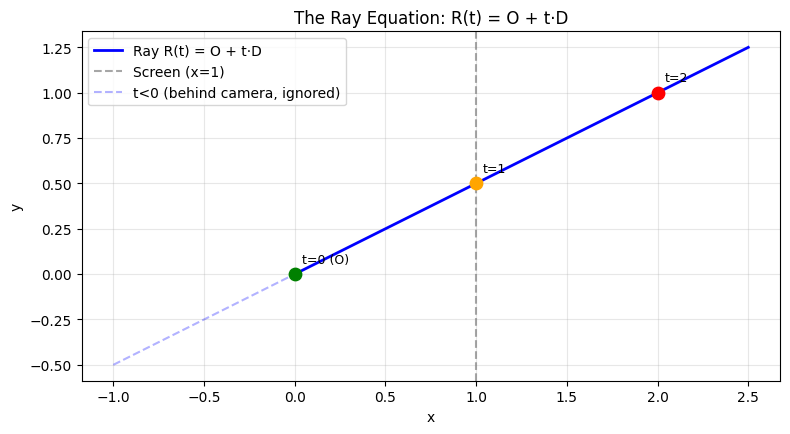

In [ ]:
#  Visualizing the Ray Equation

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

O_np = np.array([0.0, 0.0])
D_np = np.array([1.0, 0.5])

# Draw the ray
t_vals = np.linspace(0, 2.5, 100)
ray_pts = O_np + np.outer(t_vals, D_np)
ax.plot(ray_pts[:, 0], ray_pts[:, 1], 'b-', linewidth=2, label='Ray R(t) = O + t·D')

# Mark key points
for tv, label, color in [(0, 't=0 (O)', 'green'), (1, 't=1', 'orange'), (2, 't=2', 'red')]:
    pt = O_np + tv * D_np
    ax.scatter(*pt, s=80, color=color, zorder=5)
    ax.annotate(label, pt, textcoords="offset points", xytext=(5, 8), fontsize=9)

# Draw the "screen" at x=1
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.7, label='Screen (x=1)')

# Draw t<0 region (dashed, "behind camera")
t_neg = np.linspace(-1, 0, 30)
neg_pts = O_np + np.outer(t_neg, D_np)
ax.plot(neg_pts[:, 0], neg_pts[:, 1], 'b--', alpha=0.3, label='t<0 (behind camera, ignored)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('The Ray Equation: R(t) = O + t·D')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

<a id='section2'></a>

---

## Section 1 — Rays & Segments

### 1.1 Creating Rays in 1D

We start in a simplified world: camera at the origin, screen at the plane $x = 1$, working in $(x, y)$ only (z = 0).

```
y=+1  ↗  (ray 5)
y=+0.5 ↗ (ray 4)
y= 0  →  (ray 3)     ← camera at (0,0)
y=-0.5 ↘ (ray 2)
y=-1  ↘  (ray 1)
          x=1  (screen)
```

**Tensor shape:** `(num_pixels, 2, 3)` where dim 1 = `[origin, direction]` and dim 2 = `[x, y, z]`.

In [ ]:
# ── make_rays_1d ─────────────────────────────────────────────────────────

def make_rays_1d(num_pixels: int, y_limit: float) -> Float[Tensor, "nrays 2 3"]:
    """
    Generate rays from the origin toward a 1D screen at x=1.

    Args:
        num_pixels: Number of pixels (= number of rays)
        y_limit:    Rays span y ∈ [-y_limit, +y_limit] at x=1

    Returns:
        Tensor of shape (num_pixels, 2, 3)
        [:, 0, :] = origins   (all [0, 0, 0])
        [:, 1, :] = directions (x=1, y varies, z=0)
    """
    rays = t.zeros((num_pixels, 2, 3), dtype=t.float32)
    rays[:, 1, 0] = 1                                           # all point in +x direction
    t.linspace(-y_limit, y_limit, num_pixels, out=rays[:, 1, 1]) # y-coords evenly spaced
    # Note: rays[:, 1, 1] is a VIEW — linspace writes directly into rays
    return rays


# ── Inspect the output ───────────────────────────────────────────────────
rays = make_rays_1d(5, 1.0)

print(f"Shape: {rays.shape}  →  (num_pixels=5, 2, xyz=3)")
print()
print("Full tensor:")
for i, ray in enumerate(rays):
    origin = ray[0].tolist()
    direction = ray[1].tolist()
    print(f"  Ray {i+1}: origin={origin}  direction={direction}")

Shape: torch.Size([5, 2, 3])  →  (num_pixels=5, 2, xyz=3)

Full tensor:
  Ray 1: origin=[0.0, 0.0, 0.0]  direction=[1.0, -1.0, 0.0]
  Ray 2: origin=[0.0, 0.0, 0.0]  direction=[1.0, -0.5, 0.0]
  Ray 3: origin=[0.0, 0.0, 0.0]  direction=[1.0, 0.0, 0.0]
  Ray 4: origin=[0.0, 0.0, 0.0]  direction=[1.0, 0.5, 0.0]
  Ray 5: origin=[0.0, 0.0, 0.0]  direction=[1.0, 1.0, 0.0]


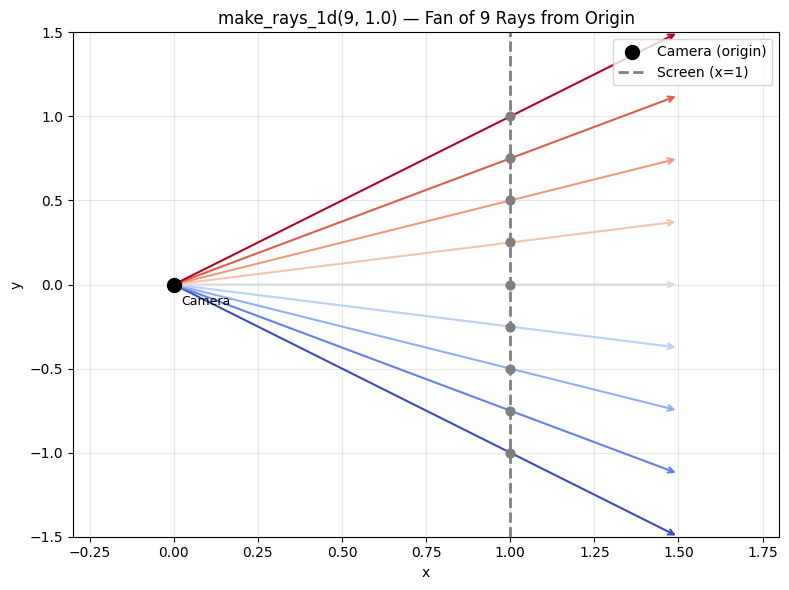

In [ ]:
# ── Visualize the fan of rays ─────────────────────────────────────────────

rays9 = make_rays_1d(9, 1.0)

fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.coolwarm(np.linspace(0, 1, len(rays9)))
for i, (ray, color) in enumerate(zip(rays9, colors)):
    ox, oy = ray[0, 0].item(), ray[0, 1].item()
    dx, dy = ray[1, 0].item(), ray[1, 1].item()
    # Draw ray from origin to x=1.5
    t_end = 1.5 / dx if dx != 0 else 1.5
    ax.annotate("", xy=(ox + t_end*dx, oy + t_end*dy), xytext=(ox, oy),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

# Mark origin and screen
ax.scatter(0, 0, s=100, color='black', zorder=5, label='Camera (origin)')
ax.annotate('Camera', (0, 0), textcoords="offset points", xytext=(5, -15), fontsize=9)
ax.axvline(x=1, color='gray', linestyle='--', linewidth=2, label='Screen (x=1)')

# Mark pixel positions on screen
y_positions = t.linspace(-1, 1, 9).numpy()
for yp in y_positions:
    ax.scatter(1, yp, s=40, color='gray', zorder=4)

ax.set_xlim(-0.3, 1.8)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('make_rays_1d(9, 1.0) — Fan of 9 Rays from Origin')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 Ray–Segment Intersection

A line segment from $\mathbf{L_1}$ to $\mathbf{L_2}$ is parametrized as:

$$\mathbf{P}(v) = \mathbf{L_1} + v \cdot (\mathbf{L_2} - \mathbf{L_1}), \quad v \in [0, 1]$$

$v=0$ → at $L_1$, $\;$ $v=1$ → at $L_2$, $\;$ $v=0.5$ → midpoint. Values outside $[0,1]$ extend to an infinite line.

---

### The Math: Deriving the Linear System

Set the ray and segment equations equal — find where they meet:

$$\mathbf{O} + u \cdot \mathbf{D} = \mathbf{L_1} + v \cdot (\mathbf{L_2} - \mathbf{L_1})$$

Rearrange (unknowns $u, v$ on the left):

$$u \cdot \mathbf{D} - v \cdot (\mathbf{L_2} - \mathbf{L_1}) = \mathbf{L_1} - \mathbf{O}$$

In matrix form — a **2×2 linear system** $A \mathbf{x} = \mathbf{b}$:

$$\underbrace{\begin{bmatrix} D_x & (L_{1x} - L_{2x}) \\ D_y & (L_{1y} - L_{2y}) \end{bmatrix}}_{A} \begin{bmatrix} u \\ v \end{bmatrix} = \underbrace{\begin{bmatrix} L_{1x} - O_x \\ L_{1y} - O_y \end{bmatrix}}_{\mathbf{b}}$$

**Cramer's Rule** (what `torch.linalg.solve` computes):

$$\det(A) = D_x(L_{1y}-L_{2y}) - (L_{1x}-L_{2x})D_y$$

$$u = \frac{(L_{1x}-O_x)(L_{1y}-L_{2y}) - (L_{1x}-L_{2x})(L_{1y}-O_y)}{\det(A)}$$

$$v = \frac{D_x(L_{1y}-O_y) - (L_{1x}-O_x)D_y}{\det(A)}$$

**Intersection is valid when:**
- $\det(A) \neq 0$ — lines are not parallel
- $u \geq 0$ — hit point is in front of the camera
- $v \in [0,1]$ — hit point is on the segment (not its infinite extension)

In [ ]:
# ── Worked Example: Computing Intersection by Hand ────────────────────────

# Ray: O=[0,0], D=[1,0.5]
# Segment: L1=[1,-1], L2=[1,1]  (vertical bar at x=1)

O = t.tensor([0.0, 0.0])
D = t.tensor([1.0, 0.5])
L1 = t.tensor([1.0, -1.0])
L2 = t.tensor([1.0,  1.0])

# Build A and b
A = t.stack([D, L1 - L2], dim=-1)
b = L1 - O

print("Matrix A:")
print(f"  {A.numpy()}")
print(f"\nVector b: {b.tolist()}")

# Determinant
det = t.linalg.det(A).item()
print(f"\ndet(A) = {det:.4f}  {'✓ non-singular' if abs(det) > 1e-8 else '✗ SINGULAR'}")

# Solve
sol = t.linalg.solve(A, b)
u, v = sol[0].item(), sol[1].item()
print(f"\nSolution:")
print(f"  u = {u:.4f}  {'✓ (>= 0)' if u >= 0 else '✗ (< 0, behind camera)'}")
print(f"  v = {v:.4f}  {'✓ (in [0,1])' if 0 <= v <= 1 else '✗ (outside segment)'}")

intersects = (u >= 0.0) and (0.0 <= v <= 1.0)
print(f"\nIntersects: {intersects}")

if intersects:
    hit_point = O + u * D
    print(f"Hit point: O + u·D = {O.tolist()} + {u:.2f}·{D.tolist()} = {hit_point.tolist()}")

Matrix A:
  [[ 1.   0. ]
 [ 0.5 -2. ]]

Vector b: [1.0, -1.0]

det(A) = -2.0000  ✓ non-singular

Solution:
  u = 1.0000  ✓ (>= 0)
  v = 0.7500  ✓ (in [0,1])

Intersects: True
Hit point: O + u·D = [0.0, 0.0] + 1.00·[1.0, 0.5] = [1.0, 0.5]


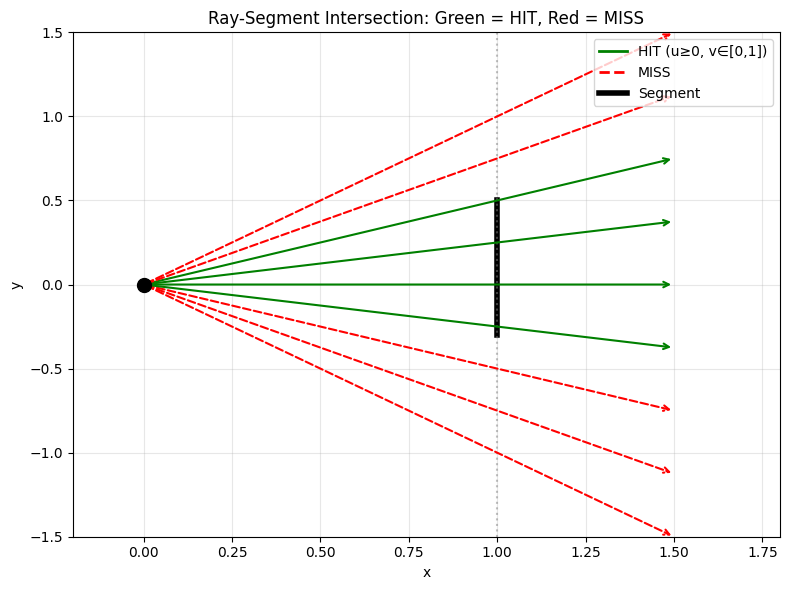

Hits: [4, 5, 6, 7]


In [ ]:
# ── Visualize: which rays hit the segment? ────────────────────────────────

def intersect_ray_1d(ray: Float[Tensor, "2 3"], segment: Float[Tensor, "2 3"]) -> bool:
    """Check if a single ray intersects a single segment."""
    O, D = ray[0, :2], ray[1, :2]
    L1, L2 = segment[0, :2], segment[1, :2]

    mat = t.stack([D, L1 - L2], dim=-1)
    vec = L1 - O

    try:
        sol = t.linalg.solve(mat, vec)
    except RuntimeError:
        return False  # singular matrix — parallel lines

    u, v = sol[0].item(), sol[1].item()
    return (u >= 0.0) and (0.0 <= v <= 1.0)


# Test with a segment that only covers part of the screen
rays = make_rays_1d(9, 1.0)
segment = t.tensor([[1.0, -0.3, 0.0], [1.0, 0.5, 0.0]])  # partial vertical bar

hits = [intersect_ray_1d(ray, segment) for ray in rays]

fig, ax = plt.subplots(figsize=(8, 6))

y_vals = t.linspace(-1, 1, 9).numpy()
for i, (yv, hit) in enumerate(zip(y_vals, hits)):
    color = 'green' if hit else 'red'
    style = '-' if hit else '--'
    label = 'HIT' if hit else 'MISS'
    ax.annotate("", xy=(1.5, 1.5 * yv), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5, linestyle=style))

# Draw the segment
seg_ys = [segment[0, 1].item(), segment[1, 1].item()]
ax.plot([1, 1], seg_ys, 'k-', linewidth=4, label=f'Segment [{seg_ys[0]}, {seg_ys[1]}]')
ax.scatter(0, 0, s=100, color='black', zorder=5, label='Camera')
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.5)

# Legend patches
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='HIT (u≥0, v∈[0,1])'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='MISS'),
    Line2D([0], [0], color='black', lw=4, label='Segment'),
]
ax.legend(handles=legend_elements)
ax.set_xlim(-0.2, 1.8)
ax.set_ylim(-1.5, 1.5)
ax.set_title('Ray-Segment Intersection: Green = HIT, Red = MISS')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Hits: {[i+1 for i, h in enumerate(hits) if h]}")

<a id='section3'></a>

---

## Section 2 — Batched Operations

### 2.1 The Core Insight: Everything at Once

Instead of looping: **create a (rays × segments) grid and solve everything simultaneously.**

```
          Seg 0   Seg 1   Seg 2  ...  Seg N
Ray 0   [ hit?   hit?    hit?   ...   hit? ]
Ray 1   [ hit?   hit?    hit?   ...   hit? ]
  ⋮
Ray M   [ hit?   hit?    hit?   ...   hit? ]
                                ↓
         .any(dim=-1) → did ray i hit ANYTHING?
```

**Why looping hurts:** Python has overhead per iteration. GPUs can run thousands of matrix solves *in parallel*. Expressing the problem as a tensor operation lets the hardware do what it's built for.

---

### 📐 The Math: Determinant & Singular Matrices

For a $2 \times 2$ matrix $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$:

$$\det(A) = ad - bc$$

Geometrically, $|\det(A)|$ = **area of the parallelogram** spanned by the two column vectors.

- $\det(A) \neq 0$ → columns span 2D space → unique solution exists ✓  
- $\det(A) = 0$ → columns are parallel → no unique intersection ✗

**The batch trick for singular matrices:**
1. Find singular matrices: `is_singular = dets.abs() < 1e-8`
2. Replace with identity $I$ (always solvable, returns $x = b$)
3. Solve all matrices at once
4. Mask: `result & ~is_singular`

Why $10^{-8}$ and not exactly 0? Floating-point arithmetic introduces tiny rounding errors. A "truly parallel" case might give $\det = 0.000000000003$.

Normal matrix — det = -2.00  → unique solution exists ✓
Singular matrix — det = -0.000000  → NO unique solution ✗



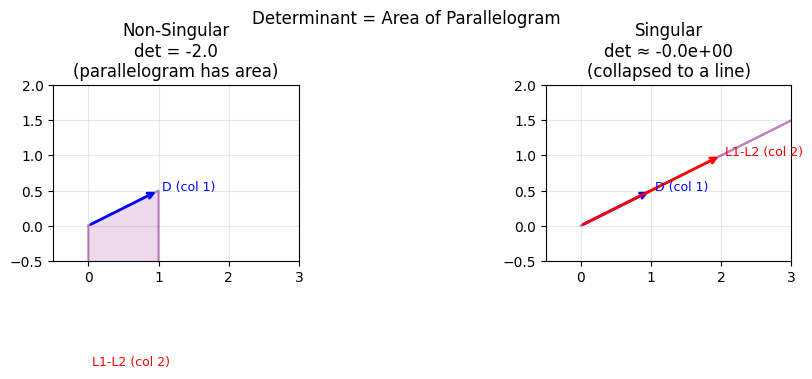

In [ ]:
# ── Determinant Intuition ─────────────────────────────────────────────────

# Case 1: Normal case — columns span 2D
A1 = t.tensor([[1.0, 0.0],
               [0.5, -2.0]])
det1 = t.linalg.det(A1).item()
print(f"Normal matrix — det = {det1:.2f}  → unique solution exists ✓")

# Case 2: Singular case — parallel columns
A2 = t.tensor([[1.0, 2.0],    # column 2 = 2 * column 1
               [0.5, 1.0]])
det2 = t.linalg.det(A2).item()
print(f"Singular matrix — det = {det2:.6f}  → NO unique solution ✗")

print()

# Visualize what det=0 means geometrically
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, A, det, title in [
    (axes[0], A1.numpy(), det1, f'Non-Singular\ndet = {det1:.1f}\n(parallelogram has area)'),
    (axes[1], A2.numpy(), det2, f'Singular\ndet ≈ {det2:.1e}\n(collapsed to a line)')
]:
    col1 = A[:, 0]
    col2 = A[:, 1]
    origin = np.zeros(2)

    ax.annotate("", xy=col1, xytext=origin,
                arrowprops=dict(arrowstyle="->", color='blue', lw=2))
    ax.annotate("", xy=col2, xytext=origin,
                arrowprops=dict(arrowstyle="->", color='red', lw=2))
    ax.text(col1[0]+0.05, col1[1], 'D (col 1)', color='blue', fontsize=9)
    ax.text(col2[0]+0.05, col2[1], 'L1-L2 (col 2)', color='red', fontsize=9)

    # Draw parallelogram
    para = np.array([origin, col1, col1+col2, col2, origin])
    ax.fill(para[:, 0], para[:, 1], alpha=0.15, color='purple')
    ax.plot(para[:, 0], para[:, 1], 'purple', alpha=0.4)

    ax.set_xlim(-0.5, 3); ax.set_ylim(-0.5, 2)
    ax.set_title(title); ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Determinant = Area of Parallelogram', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Broadcasting Intuition ────────────────────────────────────────────────
# When two tensors have compatible shapes, PyTorch broadcasts the smaller
# one along leading dimensions automatically.

print("=== Broadcasting Examples ===")
print()

# Example 1: Adding bias to each row
weights = t.tensor([[1., 2.], [3., 4.], [5., 6.]])  # (3, 2)
bias    = t.tensor([10., 20.])                        # (2,)
result  = weights + bias                              # bias gets copied 3 times
print(f"weights shape: {weights.shape}")
print(f"bias shape:    {bias.shape}")
print(f"result shape:  {result.shape}")
print(f"result:\n{result}")
print()

# Example 2: The operator precedence GOTCHA
v = t.tensor([0.2, 0.8, 1.5, -0.3])

# WRONG — evaluates as v >= (0 & v) <= 1 → TypeError or wrong result
# valid_wrong = v >= 0 & v <= 1  # DO NOT DO THIS

# CORRECT — always parenthesize
valid_correct = (v >= 0) & (v <= 1)
print(f"v = {v.tolist()}")
print(f"(v >= 0) & (v <= 1) = {valid_correct.tolist()}")
print(f"Expected:              [True, True, False, False]")
print()

# Example 3: .any() for logical reduction
hit_matrix = t.tensor([
    [False, True,  False],   # ray 0: hits seg 1
    [False, False, False],   # ray 1: misses everything
    [True,  False, True],    # ray 2: hits seg 0 and seg 2
])
print(f"hit_matrix (3 rays × 3 segments):\n{hit_matrix}")
print(f"any hit per ray: {hit_matrix.any(dim=-1).tolist()}  ← dim=-1 collapses segments")

=== Broadcasting Examples ===

weights shape: torch.Size([3, 2])
bias shape:    torch.Size([2])
result shape:  torch.Size([3, 2])
result:
tensor([[11., 22.],
        [13., 24.],
        [15., 26.]])

v = [0.20000000298023224, 0.800000011920929, 1.5, -0.30000001192092896]
(v >= 0) & (v <= 1) = [True, True, False, False]
Expected:              [True, True, False, False]

hit_matrix (3 rays × 3 segments):
tensor([[False,  True, False],
        [False, False, False],
        [ True, False,  True]])
any hit per ray: [True, False, True]  ← dim=-1 collapses segments


In [ ]:
# ── einops.repeat Intuition ───────────────────────────────────────────────

print("=== einops.repeat vs raw PyTorch ===")
print()

# Task: repeat a (3,) vector to create a (3, 4) matrix where each row is the vector
v = t.tensor([1., 2., 3.])

# Raw PyTorch — cryptic
raw = v.unsqueeze(0).expand(4, -1)   # (1,3) → expand to (4,3)
print(f"Raw PyTorch: v.unsqueeze(0).expand(4,-1)")
print(f"  Shape: {raw.shape}")
print(f"  Result:\n{raw}")
print()

# einops — readable
einops_out = einops.repeat(v, "d -> n d", n=4)
print(f"einops: repeat(v, 'd -> n d', n=4)")
print(f"  Shape: {einops_out.shape}")
print(f"  Result:\n{einops_out}")
print()

# The pattern used in make_rays_2d
ygrid = t.tensor([-1., 0., 1.])   # 3 y-values
tiled = einops.repeat(ygrid, "y -> (y z)", z=3)
print(f"For 2D rays — repeat(ygrid, 'y -> (y z)', z=3):")
print(f"  Input:  {ygrid.tolist()}  shape {ygrid.shape}")
print(f"  Output: {tiled.tolist()}  shape {tiled.shape}")
print(f"  (each y-value repeated 3 times, once per z row)")

=== einops.repeat vs raw PyTorch ===

Raw PyTorch: v.unsqueeze(0).expand(4,-1)
  Shape: torch.Size([4, 3])
  Result:
tensor([[1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.]])

einops: repeat(v, 'd -> n d', n=4)
  Shape: torch.Size([4, 3])
  Result:
tensor([[1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.]])

For 2D rays — repeat(ygrid, 'y -> (y z)', z=3):
  Input:  [-1.0, 0.0, 1.0]  shape torch.Size([3])
  Output: [-1.0, -1.0, -1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0]  shape torch.Size([9])
  (each y-value repeated 3 times, once per z row)


In [ ]:
# ── Batched Ray-Segment Intersection ─────────────────────────────────────

def intersect_rays_1d(
    rays:     Float[Tensor, "nrays 2 3"],
    segments: Float[Tensor, "nsegments 2 3"]
) -> Bool[Tensor, "nrays"]:
    """
    For each ray, return True if it intersects ANY segment.

    Strategy:
    1. Expand to (NR, NS) grid — every (ray, segment) pair
    2. Solve all 2x2 systems at once
    3. Handle singular matrices with identity replacement + masking
    4. Collapse with .any(dim=-1)
    """
    NR = rays.size(0)
    NS = segments.size(0)

    # Drop z — work in 2D
    rays     = rays[..., :2]
    segments = segments[..., :2]

    # Expand to (NR, NS) grid
    rays     = einops.repeat(rays,     "nr p d -> nr ns p d", ns=NS)
    segments = einops.repeat(segments, "ns p d -> nr ns p d", nr=NR)

    O, D   = rays[:, :, 0],     rays[:, :, 1]
    L1, L2 = segments[:, :, 0], segments[:, :, 1]

    # Build all (NR × NS) 2x2 matrices at once
    mat = t.stack([D, L1 - L2], dim=-1)   # shape: (NR, NS, 2, 2)
    vec = L1 - O                           # shape: (NR, NS, 2)

    # Handle singular matrices
    dets = t.linalg.det(mat)               # shape: (NR, NS)
    is_singular = dets.abs() < 1e-8
    mat[is_singular] = t.eye(2)            # replace with identity

    # Solve all systems at once
    sol = t.linalg.solve(mat, vec)         # shape: (NR, NS, 2)
    u, v = sol[..., 0], sol[..., 1]

    # Valid intersection conditions
    hit = (u >= 0) & (v >= 0) & (v <= 1) & ~is_singular

    return hit.any(dim=-1)   # shape: (NR,)


# ── Test ─────────────────────────────────────────────────────────────────
rays     = make_rays_1d(9, 1.0)
segments = t.tensor([
    [[1., -0.5, 0.], [1.,  0.5, 0.]],   # seg 0: middle portion
    [[1.,  0.3, 0.], [1.,  0.9, 0.]],   # seg 1: upper portion
])

hits = intersect_rays_1d(rays, segments)
y_vals = t.linspace(-1, 1, 9)
print("Ray  y-direction  Hit?")
print("-" * 30)
for i, (yv, hit) in enumerate(zip(y_vals, hits)):
    status = '✓ HIT' if hit else '  miss'
    print(f" {i+1}    y={yv:+.3f}      {status}")

Ray  y-direction  Hit?
------------------------------
 1    y=-1.000        miss
 2    y=-0.750        miss
 3    y=-0.500      ✓ HIT
 4    y=-0.250      ✓ HIT
 5    y=+0.000      ✓ HIT
 6    y=+0.250      ✓ HIT
 7    y=+0.500      ✓ HIT
 8    y=+0.750      ✓ HIT
 9    y=+1.000        miss


In [ ]:
# ── 2D Rays: Extending to a Full Screen ──────────────────────────────────

def make_rays_2d(
    num_pixels_y: int, num_pixels_z: int,
    y_limit: float,    z_limit: float
) -> Float[Tensor, "nrays 2 3"]:
    """
    Generate a 2D grid of rays (one per pixel) from the origin.
    Screen spans y ∈ [-y_limit, +y_limit] and z ∈ [-z_limit, +z_limit] at x=1.

    Returns shape: (num_pixels_y * num_pixels_z, 2, 3)
    """
    n_pixels = num_pixels_y * num_pixels_z
    ygrid    = t.linspace(-y_limit, y_limit, num_pixels_y)
    zgrid    = t.linspace(-z_limit, z_limit, num_pixels_z)

    rays = t.zeros((n_pixels, 2, 3), dtype=t.float32)
    rays[:, 1, 0] = 1   # all point in +x direction

    # Tile y-values: [-1,-1,-1, 0,0,0, 1,1,1] for a 3x3 screen
    rays[:, 1, 1] = einops.repeat(ygrid, "y -> (y z)", z=num_pixels_z)
    # Tile z-values: [-1,0,1, -1,0,1, -1,0,1] for a 3x3 screen
    rays[:, 1, 2] = einops.repeat(zgrid, "z -> (y z)", y=num_pixels_y)

    return rays


# Show the 3x3 grid structure
rays_3x3 = make_rays_2d(3, 3, 1.0, 1.0)
print("3x3 ray grid — direction vectors (y, z components):")
print("       z=-1    z=0    z=+1")
print("-" * 35)
for row in range(3):
    y_label = ["y=+1", "y= 0", "y=-1"][row]
    row_dirs = []
    for col in range(3):
        idx = row * 3 + col
        yz = rays_3x3[idx, 1, 1:].tolist()
        row_dirs.append(f"({yz[0]:+.0f},{yz[1]:+.0f})")
    print(f"{y_label}: " + "  ".join(row_dirs))

print(f"\nTotal rays: {rays_3x3.shape[0]}  (= 3×3 pixels)")

3x3 ray grid — direction vectors (y, z components):
       z=-1    z=0    z=+1
-----------------------------------
y=+1: (-1,-1)  (-1,+0)  (-1,+1)
y= 0: (+0,-1)  (+0,+0)  (+0,+1)
y=-1: (+1,-1)  (+1,+0)  (+1,+1)

Total rays: 9  (= 3×3 pixels)


<a id='section4'></a>

---

## 🔺 Section 3 — Triangles & Mesh Rendering

### 3.1 Triangle Parametrization (Barycentric Coordinates)

Any point inside triangle $ABC$ can be written as:

$$\mathbf{P}(u,v) = \mathbf{A} + u(\mathbf{B}-\mathbf{A}) + v(\mathbf{C}-\mathbf{A})$$

Or equivalently as a **weighted average of vertices**:

$$\mathbf{P}(u,v) = (1-u-v)\mathbf{A} + u\mathbf{B} + v\mathbf{C}$$

The weights $(1-u-v,\, u,\, v)$ sum to 1 and are called **barycentric coordinates**.

**Why is $u + v \leq 1$ the triangle boundary?**  
The line $u + v = 1$ connects $B$ ($u=1,v=0$) to $C$ ($u=0,v=1$) — that's the opposite edge $BC$.  
Staying below it ($u + v \leq 1$) keeps you on the $A$-side — **inside the triangle**.

```
       C (u=0, v=1)
      /|
     / |   ← u+v=1 boundary (edge BC)
  v /  |
   /   |
  A────B
(0,0) (1,0)
     u →
```

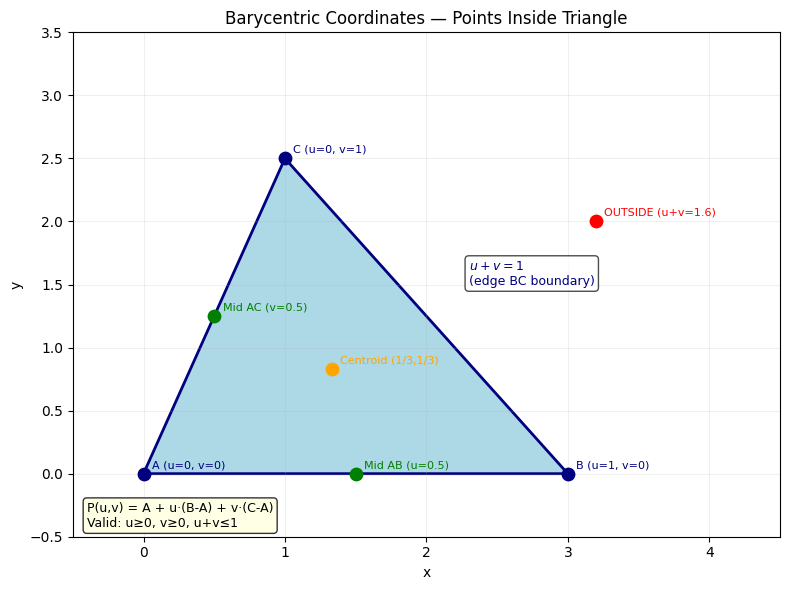

(u, v)          Location                          u+v  Inside?
-----------------------------------------------------------------
(0.00, 0.00)      A (u=0, v=0)                   0.00    ✓
(1.00, 0.00)      B (u=1, v=0)                   1.00    ✓
(0.00, 1.00)      C (u=0, v=1)                   1.00    ✓
(0.50, 0.00)      Mid AB (u=0.5)                 0.50    ✓
(0.00, 0.50)      Mid AC (v=0.5)                 0.50    ✓
(0.33, 0.33)      Centroid (1/3,1/3)             0.67    ✓
(0.80, 0.80)      OUTSIDE (u+v=1.6)              1.60    ✗


In [ ]:
# ── Barycentric Coordinates Visualization ────────────────────────────────

A = np.array([0., 0.])
B = np.array([3., 0.])
C = np.array([1., 2.5])

def barycentric_to_cartesian(u, v, A, B, C):
    return A + u*(B-A) + v*(C-A)

fig, ax = plt.subplots(figsize=(8, 6))

# Draw filled triangle
triangle = plt.Polygon([A, B, C], fill=True, facecolor='lightblue', edgecolor='navy', lw=2)
ax.add_patch(triangle)

# Landmark points
landmarks = [
    (0,    0,    A,                          'A (u=0, v=0)',     'navy'),
    (1,    0,    B,                          'B (u=1, v=0)',     'navy'),
    (0,    1,    C,                          'C (u=0, v=1)',     'navy'),
    (0.5,  0,    barycentric_to_cartesian(0.5,  0,   A, B, C),  'Mid AB (u=0.5)',   'green'),
    (0,    0.5,  barycentric_to_cartesian(0,    0.5, A, B, C),  'Mid AC (v=0.5)',   'green'),
    (1/3, 1/3,   barycentric_to_cartesian(1/3, 1/3,  A, B, C),  'Centroid (1/3,1/3)', 'orange'),
    (0.8,  0.8,  barycentric_to_cartesian(0.8,  0.8, A, B, C),  'OUTSIDE (u+v=1.6)', 'red'),
]

for u, v, pt, lbl, clr in landmarks:
    ax.scatter(*pt, s=80, color=clr, zorder=5)
    ax.annotate(lbl, pt, textcoords="offset points", xytext=(6, 4), fontsize=8, color=clr)

# Show u+v=1 constraint
ax.text(2.3, 1.5, '$u + v = 1$\n(edge BC boundary)', fontsize=9, color='navy',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 3.5)
ax.set_title('Barycentric Coordinates — Points Inside Triangle')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.grid(True, alpha=0.2)

# Add formula
ax.text(0.02, 0.02, 'P(u,v) = A + u·(B-A) + v·(C-A)\nValid: u≥0, v≥0, u+v≤1',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Print the table
print(f"{'(u, v)':<15} {'Location':<30} {'u+v':>6} {'Inside?':>8}")
print("-" * 65)
for u, v, pt, lbl, _ in landmarks:
    inside = (u >= 0) and (v >= 0) and (u + v <= 1)
    print(f"({u:.2f}, {v:.2f})      {lbl:<30} {u+v:.2f}    {'✓' if inside else '✗'}")

### 3.2 Ray–Triangle Intersection: The Full Derivation

We want to find where ray $\mathbf{R}(s) = \mathbf{O} + s\mathbf{D}$ pierces the triangle's plane.

Set $\mathbf{R}(s) = \mathbf{P}(u,v)$:

$$\mathbf{O} + s\mathbf{D} = \mathbf{A} + u(\mathbf{B}-\mathbf{A}) + v(\mathbf{C}-\mathbf{A})$$

Rearranging:

$$s\mathbf{D} - u(\mathbf{B}-\mathbf{A}) - v(\mathbf{C}-\mathbf{A}) = \mathbf{A} - \mathbf{O}$$

Written as a **3×3 linear system** $M \cdot [s, u, v]^\top = \mathbf{O} - \mathbf{A}$:

$$\underbrace{\begin{bmatrix} -D_x & (B_x-A_x) & (C_x-A_x) \\ -D_y & (B_y-A_y) & (C_y-A_y) \\ -D_z & (B_z-A_z) & (C_z-A_z) \end{bmatrix}}_{M = [-\mathbf{D}\;|\;(\mathbf{B}-\mathbf{A})\;|\;(\mathbf{C}-\mathbf{A})]} \begin{bmatrix} s \\ u \\ v \end{bmatrix} = \begin{bmatrix} O_x-A_x \\ O_y-A_y \\ O_z-A_z \end{bmatrix}$$

**Why $\det(M) = 0$ means the ray is parallel to the triangle:**  
The last two columns $(\mathbf{B}-\mathbf{A})$ and $(\mathbf{C}-\mathbf{A})$ span the triangle's plane. If $\det = 0$, the ray direction $-\mathbf{D}$ lies in that same plane — the ray travels parallel to the triangle and never pierces it.

| Variable | Meaning | Validity Condition |
|---|---|---|
| $s$ | Steps along ray to the hit | $s \geq 0$ (in front of camera) |
| $u$ | Barycentric coord toward $B$ | $u \geq 0$ |
| $v$ | Barycentric coord toward $C$ | $v \geq 0$ |
| — | Inside triangle constraint | $u + v \leq 1$ |

In [ ]:
# ── Worked Example: Triangle-Ray Intersection ─────────────────────────────

A = t.tensor([1., -1., -1.])
B = t.tensor([1.,  1., -1.])
C = t.tensor([1.,  0.,  1.])
O = t.tensor([0.,  0.,  0.])   # camera at origin
D = t.tensor([1.,  0.,  0.])   # ray pointing in +x direction

print("Triangle vertices:")
print(f"  A = {A.tolist()}")
print(f"  B = {B.tolist()}")
print(f"  C = {C.tolist()}")
print(f"\nRay:  O={O.tolist()},  D={D.tolist()}")
print()

# Build the 3x3 system
M = t.stack([-D, B-A, C-A], dim=-1)
rhs = O - A

print("Matrix M = [-D | B-A | C-A]:")
print(M.numpy())
print(f"\nRHS (O - A): {rhs.tolist()}")

det_M = t.linalg.det(M).item()
print(f"\ndet(M) = {det_M:.4f}  {'✓ non-singular' if abs(det_M) > 1e-8 else '✗ SINGULAR'}")

sol = t.linalg.solve(M, rhs)
s, u, v = sol.unbind(-1)
s, u, v = s.item(), u.item(), v.item()

print(f"\nSolution:")
print(f"  s = {s:.4f}  {'✓ (>= 0)' if s >= 0 else '✗'}")
print(f"  u = {u:.4f}  {'✓ (>= 0)' if u >= 0 else '✗'}")
print(f"  v = {v:.4f}  {'✓ (>= 0)' if v >= 0 else '✗'}")
print(f"  u+v = {u+v:.4f}  {'✓ (<= 1)' if u+v <= 1 else '✗'}")

intersects = (s >= 0) and (u >= 0) and (v >= 0) and (u+v <= 1)
print(f"\nIntersects: {intersects}")
if intersects:
    hit = O + s * D
    print(f"Hit point: O + s·D = {O.tolist()} + {s:.2f}·{D.tolist()} = {hit.tolist()}")
    # Verify using barycentric coords
    hit_bary = A + u*(B-A) + v*(C-A)
    print(f"Verify via barycentric: A+u(B-A)+v(C-A) = {hit_bary.tolist()}  (should match)")

Triangle vertices:
  A = [1.0, -1.0, -1.0]
  B = [1.0, 1.0, -1.0]
  C = [1.0, 0.0, 1.0]

Ray:  O=[0.0, 0.0, 0.0],  D=[1.0, 0.0, 0.0]

Matrix M = [-D | B-A | C-A]:
[[-1.  0.  0.]
 [-0.  2.  1.]
 [-0.  0.  2.]]

RHS (O - A): [-1.0, 1.0, 1.0]

det(M) = -4.0000  ✓ non-singular

Solution:
  s = 1.0000  ✓ (>= 0)
  u = 0.2500  ✓ (>= 0)
  v = 0.5000  ✓ (>= 0)
  u+v = 0.7500  ✓ (<= 1)

Intersects: True
Hit point: O + s·D = [0.0, 0.0, 0.0] + 1.00·[1.0, 0.0, 0.0] = [1.0, 0.0, 0.0]
Verify via barycentric: A+u(B-A)+v(C-A) = [1.0, 0.0, 0.0]  (should match)


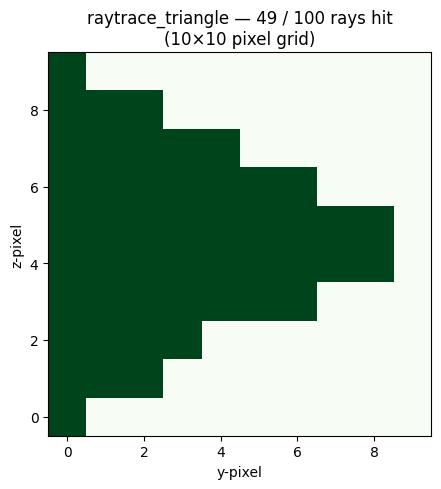

In [ ]:
# ── raytrace_triangle: Batched Over All Rays ─────────────────────────────

def raytrace_triangle(
    rays:     Float[Tensor, "nrays 2 3"],
    triangle: Float[Tensor, "3 3"]
) -> Bool[Tensor, "nrays"]:
    """
    For each ray, return True if it hits the given triangle.

    Solves: [-D | B-A | C-A] · [s,u,v]^T = O - A
    Valid intersection: s>=0, u>=0, v>=0, u+v<=1, det≠0
    """
    NR = rays.size(0)

    # Repeat triangle vertices for all rays
    A, B, C = einops.repeat(triangle, "pts dims -> pts NR dims", NR=NR)
    O, D    = rays.unbind(dim=1)

    # Build NR 3x3 matrices at once
    mat = t.stack([-D, B-A, C-A], dim=-1)   # shape: (NR, 3, 3)

    dets = t.linalg.det(mat)
    is_singular = dets.abs() < 1e-8
    mat[is_singular] = t.eye(3)

    sol = t.linalg.solve(mat, O - A)         # shape: (NR, 3)
    s, u, v = sol.unbind(dim=-1)             # each shape: (NR,)

    return (s >= 0) & (u >= 0) & (v >= 0) & (u + v <= 1) & ~is_singular


# Test with a simple triangle in the x=1 plane
triangle = t.tensor([[1., -1., -1.],
                     [1.,  1., -1.],
                     [1.,  0.,  1.]])

rays_2d = make_rays_2d(10, 10, 1.0, 1.0)
hits = raytrace_triangle(rays_2d, triangle)

# Render as image
img = hits.reshape(10, 10).float().numpy()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, origin='lower', cmap='Greens', vmin=0, vmax=1)
ax.set_title(f'raytrace_triangle — {hits.sum()} / {len(hits)} rays hit\n(10×10 pixel grid)')
ax.set_xlabel('y-pixel'); ax.set_ylabel('z-pixel')
plt.tight_layout()
plt.show()

### 3.3 Full Mesh Rendering

A mesh is a collection of triangles. The Pikachu model has **412 triangles** — every ear, cheek, and tail tip is built from flat faces.

For each ray we want the **distance to the nearest triangle** (or $\infty$ if it misses everything). This is depth ordering — a ray can pass through multiple triangles; we want the first (closest) hit.

**Scale:** 120×120 pixels × 412 triangles = **5.93 million intersection checks** — all in one batched call.

**Key line:** `s *= D[..., 0]` — scaling $s$ by $D_x$ converts from "ray-units" to x-axis distance, enabling correct depth comparison across rays with different directions.

Output shape: torch.Size([400])  (one distance per ray)
Rays that hit something: 128 / 400
Distance range: [1.000, 1.000]

Example: distances for first 5 rays (inf = no hit):
  Ray 0: ∞ (miss)
  Ray 1: ∞ (miss)
  Ray 2: ∞ (miss)
  Ray 3: ∞ (miss)
  Ray 4: ∞ (miss)


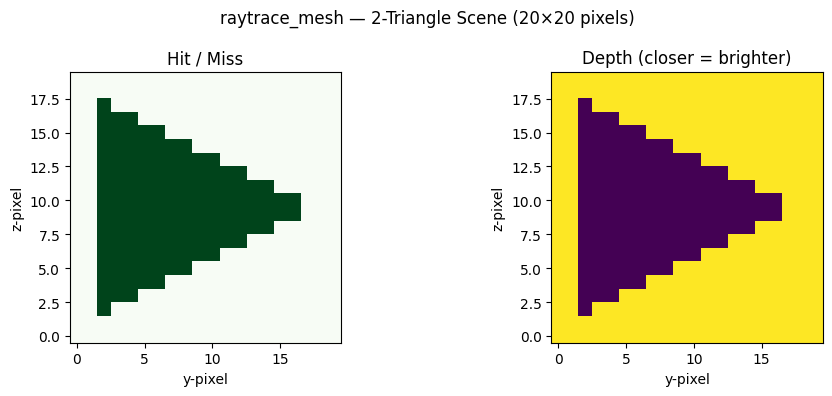

In [ ]:
# ── raytrace_mesh: Batched Over All Rays × All Triangles ─────────────────

def raytrace_mesh(
    rays:      Float[Tensor, "nrays 2 3"],
    triangles: Float[Tensor, "ntriangles 3 3"]
) -> Float[Tensor, "nrays"]:
    """
    For each ray, return the x-distance to the nearest triangle, or inf.

    Batch dimensions: (NR, NT) — every ray × every triangle simultaneously.
    """
    NR = rays.size(0)
    NT = triangles.size(0)

    # Expand to (NR, NT) grid — shape: (pts, NR, NT, dims)
    triangles = einops.repeat(triangles, "NT pts dims -> pts NR NT dims", NR=NR)
    A, B, C   = triangles                         # each: (NR, NT, 3)

    rays = einops.repeat(rays, "NR pts dims -> pts NR NT dims", NT=NT)
    O, D = rays                                   # each: (NR, NT, 3)

    # Build (NR, NT) batch of 3x3 matrices
    mat = t.stack([-D, B-A, C-A], dim=-1)         # (NR, NT, 3, 3)

    dets = t.linalg.det(mat)                       # (NR, NT)
    is_singular = dets.abs() < 1e-8
    mat[is_singular] = t.eye(3)

    sol = t.linalg.solve(mat, O - A)              # (NR, NT, 3)
    s, u, v = sol.unbind(-1)                      # each: (NR, NT)
    s *= D[..., 0]                                 # scale to x-distance

    intersects = (s >= 0) & (u >= 0) & (v >= 0) & (u + v <= 1) & ~is_singular
    s[~intersects] = float('inf')

    # For each ray: minimum distance across all triangles
    return einops.reduce(s, "NR NT -> NR", "min")


# ── Demo: Render a simple 2-triangle scene ────────────────────────────────
simple_mesh = t.tensor([
    [[1., -1., -1.], [1.,  1., -1.], [1.,  0.,  1.]],   # triangle 0
    [[1., -0.5, -0.5], [1., 0.5, -0.5], [1., 0., 0.5]], # triangle 1 (in front)
])

rays_render = make_rays_2d(20, 20, 1.2, 1.2)
dists = raytrace_mesh(rays_render, simple_mesh)

print(f"Output shape: {dists.shape}  (one distance per ray)")
print(f"Rays that hit something: {t.isfinite(dists).sum()} / {len(dists)}")
print(f"Distance range: [{dists[t.isfinite(dists)].min():.3f}, {dists[t.isfinite(dists)].max():.3f}]")

# Show a sample of per-ray distances
print("\nExample: distances for first 5 rays (inf = no hit):")
for i in range(5):
    d = dists[i].item()
    print(f"  Ray {i}: {d:.4f}" if t.isfinite(dists[i]) else f"  Ray {i}: ∞ (miss)")

# Render as depth image
img = dists.reshape(20, 20)
img_display = t.where(t.isfinite(img), img, t.zeros_like(img))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow((t.isfinite(img)).float().numpy(), origin='lower', cmap='Greens')
axes[0].set_title('Hit / Miss')
axes[1].imshow(img_display.numpy(), origin='lower', cmap='viridis_r')
axes[1].set_title('Depth (closer = brighter)')
for ax in axes: ax.set_xlabel('y-pixel'); ax.set_ylabel('z-pixel')
plt.suptitle('raytrace_mesh — 2-Triangle Scene (20×20 pixels)')
plt.tight_layout()
plt.show()

<a id='section5'></a>

---

## 💡 Section 4 — Lighting & GPU Acceleration (Bonus)

### 4.1 Lambertian Lighting

So far, pixel brightness = inverse distance. Lambertian lighting makes it physically grounded: **surfaces facing the light are bright; surfaces facing away are dark.**

**Real-world analogy:** hold a piece of paper flat under a ceiling lamp — it's bright. Tilt it 90° to edge-on — it's dark.

---

### 📐 The Math: Surface Normals & Dot Products

**Step 1 — Surface Normal via Cross Product**

The normal to triangle $ABC$ is perpendicular to both edge vectors:

$$\mathbf{n} = (\mathbf{C}-\mathbf{A}) \times (\mathbf{B}-\mathbf{A})$$

Cross product formula:
$$\mathbf{a} \times \mathbf{b} = \begin{bmatrix} a_y b_z - a_z b_y \\ a_z b_x - a_x b_z \\ a_x b_y - a_y b_x \end{bmatrix}$$

**Step 2 — Normalize**
$$\hat{\mathbf{n}} = \frac{\mathbf{n}}{|\mathbf{n}|}, \quad |\mathbf{n}| = \sqrt{n_x^2 + n_y^2 + n_z^2}$$

**Step 3 — Lambertian Intensity**
$$\text{intensity} = \hat{\mathbf{n}} \cdot \hat{\mathbf{L}} = |\hat{\mathbf{n}}||\hat{\mathbf{L}}|\cos\theta = \cos\theta$$

| Angle $\theta$ | $\cos\theta$ | Meaning |
|---|---|---|
| $0°$ | $1.0$ | Face-on to light — maximum brightness |
| $45°$ | $0.71$ | Angled — partial brightness |
| $90°$ | $0.0$ | Edge-on — dark |
| $>90°$ | $<0$ | Back-face — clamped to $0$ |

**Step 4 — Final Intensity**
$$I_{\text{final}} = \text{clamp}(\hat{\mathbf{n}} \cdot \hat{\mathbf{L}}, \min=0) + I_{\text{ambient}}$$

In [ ]:
# ── Lambertian Lighting Demo ──────────────────────────────────────────────

# Cross product and normal computation
A = t.tensor([1., 0., 0.])
B = t.tensor([1., 1., 0.])
C = t.tensor([1., 0., 1.])

e1 = C - A   # edge 1
e2 = B - A   # edge 2
n  = t.linalg.cross(e1, e2)   # normal = e1 × e2
n_hat = n / n.norm()           # normalized

print("Triangle in the x=1 plane:")
print(f"  e1 = C-A = {e1.tolist()}")
print(f"  e2 = B-A = {e2.tolist()}")
print(f"  n  = e1×e2 = {n.tolist()}")
print(f"  n̂  = {n_hat.tolist()}")
print()

# Test against several light directions
lights = [
    (t.tensor([-1., 0., 0.]),  "Facing camera (-x direction)"),
    (t.tensor([-0.7, 0.7, 0.]), "Diagonal front-top"),
    (t.tensor([0.,  1., 0.]),  "Perpendicular (edge-on)"),
    (t.tensor([1.,  0., 0.]),  "Back face (+x direction)"),
]

print(f"{'Light direction':<35} {'dot product':>12} {'intensity':>10}")
print("-" * 60)
for L, desc in lights:
    L_hat = L / L.norm()
    dot = (n_hat * L_hat).sum().item()
    intensity = max(0, dot)
    bar = '█' * int(intensity * 15)
    print(f"{desc:<35} {dot:+.4f}       {intensity:.4f}  {bar}")

Triangle in the x=1 plane:
  e1 = C-A = [0.0, 0.0, 1.0]
  e2 = B-A = [0.0, 1.0, 0.0]
  n  = e1×e2 = [-1.0, 0.0, 0.0]
  n̂  = [-1.0, 0.0, 0.0]

Light direction                      dot product  intensity
------------------------------------------------------------
Facing camera (-x direction)        +1.0000       1.0000  ███████████████
Diagonal front-top                  +0.7071       0.7071  ██████████
Perpendicular (edge-on)             +0.0000       0.0000  
Back face (+x direction)            -1.0000       0.0000  


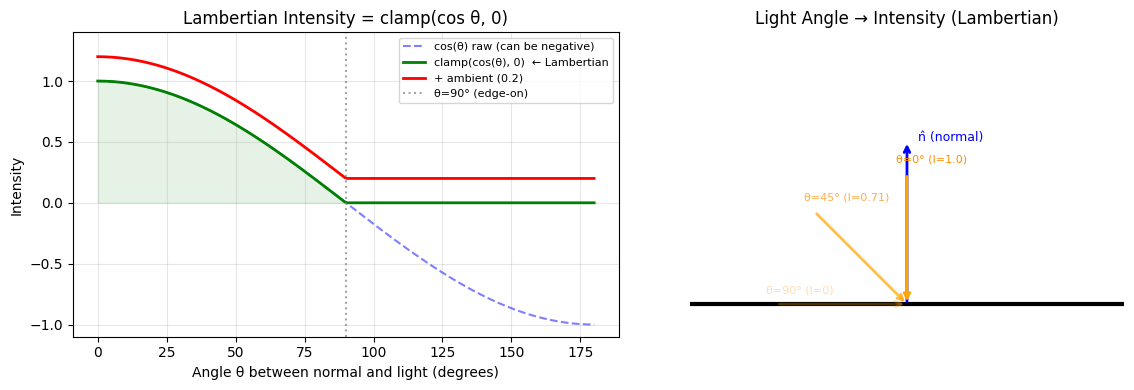

In [ ]:
# ── Visualize Lambertian Intensity vs Angle ───────────────────────────────

angles_deg = np.linspace(0, 180, 200)
angles_rad = np.radians(angles_deg)
cos_vals   = np.cos(angles_rad)
intensity  = np.maximum(0, cos_vals)           # clamp to 0
intensity_ambient = intensity + 0.2            # with ambient term

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: intensity curve
ax1.plot(angles_deg, cos_vals,         'b--', alpha=0.5, label='cos(θ) raw (can be negative)')
ax1.plot(angles_deg, intensity,        'g-',  linewidth=2, label='clamp(cos(θ), 0)  ← Lambertian')
ax1.plot(angles_deg, intensity_ambient,'r-',  linewidth=2, label='+ ambient (0.2)')
ax1.axvline(x=90, color='gray', linestyle=':', alpha=0.7, label='θ=90° (edge-on)')
ax1.fill_between(angles_deg, intensity, alpha=0.1, color='green')
ax1.set_xlabel('Angle θ between normal and light (degrees)')
ax1.set_ylabel('Intensity')
ax1.set_title('Lambertian Intensity = clamp(cos θ, 0)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1.1, 1.4)

# Right: surface diagram
ax2.set_xlim(-2, 2); ax2.set_ylim(-0.3, 2.5)
ax2.set_aspect('equal')

# Draw surface
ax2.plot([-2, 2], [0, 0], 'k-', linewidth=3, label='Surface')

# Draw normal
ax2.annotate("", xy=(0, 1.5), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", color='blue', lw=2))
ax2.text(0.1, 1.5, 'n̂ (normal)', color='blue', fontsize=9)

# Draw light rays at different angles
for angle, alpha, label in [(0, 1.0, 'θ=0° (I=1.0)'), (45, 0.7, 'θ=45° (I=0.71)'), (90, 0.3, 'θ=90° (I=0)')]:
    rad = np.radians(angle)
    lx = -np.sin(rad) * 1.2
    ly = np.cos(rad) * 1.2
    ax2.annotate("", xy=(0, 0), xytext=(lx, ly),
                 arrowprops=dict(arrowstyle="->", color='orange', lw=2, alpha=alpha))
    ax2.text(lx-0.1, ly+0.1, label, color='darkorange', fontsize=8, alpha=alpha)

ax2.set_title('Light Angle → Intensity (Lambertian)')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ── GPU Acceleration Pattern ──────────────────────────────────────────────

print("GPU Acceleration Pattern:")
print("=========================")
print()
print("  rays       = rays.to('cuda')       # move to GPU")
print("  triangles  = triangles.to('cuda')  # move to GPU")
print("  result     = raytrace_mesh(rays, triangles)  # GPU compute")
print("  result     = result.cpu()          # bring back to CPU")
print()
print("Rules:")
print("  ✓ Move tensors ONCE, outside any loops")
print("  ✓ All tensors in an operation must be on the SAME device")
print("  ✓ Move output back to CPU before display/numpy")
print()

# Show scale benefits
print("Scale comparison (120×120 image, 412 triangles, 50 frames):")
print(f"  Checks per frame: {120*120:,} rays × {412:,} triangles = {120*120*412:,}")
print(f"  Total checks:     {120*120*412*50:,}")
print()
print("  CPU (sequential):  ~8 minutes")
print("  GPU (parallel):    ~30 seconds")

# Demonstrate .to() if CUDA available
demo_tensor = t.randn(100, 3)
if t.cuda.is_available():
    gpu_tensor = demo_tensor.to('cuda')
    print(f"\ndemo_tensor.device: {demo_tensor.device}")
    print(f"gpu_tensor.device:  {gpu_tensor.device}")
    cpu_back = gpu_tensor.cpu()
    print(f"cpu_back.device:    {cpu_back.device}")
else:
    print(f"\nCUDA not available in this environment.")
    print("Run on a GPU runtime to see device transfers.")

GPU Acceleration Pattern:

  rays       = rays.to('cuda')       # move to GPU
  triangles  = triangles.to('cuda')  # move to GPU
  result     = raytrace_mesh(rays, triangles)  # GPU compute
  result     = result.cpu()          # bring back to CPU

Rules:
  ✓ Move tensors ONCE, outside any loops
  ✓ All tensors in an operation must be on the SAME device
  ✓ Move output back to CPU before display/numpy

Scale comparison (120×120 image, 412 triangles, 50 frames):
  Checks per frame: 14,400 rays × 412 triangles = 5,932,800
  Total checks:     296,640,000

  CPU (sequential):  ~8 minutes
  GPU (parallel):    ~30 seconds

CUDA not available in this environment.
Run on a GPU runtime to see device transfers.


<a id='section6'></a>

---

## Views vs Copies

**The spreadsheet analogy:**  
- A **view** is like a cell reference `=A1` — it points to the original data; changes propagate both ways.  
- A **copy** is like pasting the value — independent from that moment on.

This matters for:
- **Correctness** — accidentally modifying a view changes the source
- **Performance** — views avoid allocating new memory
- **Memory management** — holding a view keeps the source tensor alive

In [ ]:
# ── Views vs Copies in Practice ───────────────────────────────────────────

print("=== View Demo ===")
x = t.tensor([1., 2., 3., 4.])
y = x[:2]         # basic slice → VIEW
y[0] = 99.
print(f"After y[0]=99:  x={x.tolist()}  ← x was modified through the view!")
print(f"Same storage: {x.data_ptr() == y.data_ptr()}")
print()

print("=== Copy Demo ===")
x = t.tensor([1., 2., 3., 4.])
z = x[:2].clone()  # .clone() → COPY
z[0] = 99.
print(f"After z[0]=99:  x={x.tolist()}  ← x is untouched")
print(f"Same storage: {x.data_ptr() == z.data_ptr()}")
print()

print("=== Memory Leak Trap ===")
# del big won't free memory if a view of it still exists
big   = t.zeros(1000, 1000)   # 4 MB
small = big[0]                 # view — shares memory with big
del big                        # 'big' name is deleted...
# ...but 4 MB is NOT freed because 'small' still references it
print(f"small._base is None: {small._base is None}  ← False means big is still alive in memory")
print("Fix: small = big[0].clone()  — then del big actually frees memory")
print()

print("=== Practical Trap in Ray Tracing ===")
rays = t.zeros(5, 2, 3)
d    = rays[:, 1]    # VIEW — shares memory with rays
d[:] = 1.0           # modifies rays too!
print(f"After d[:]=1.0, rays[:, 1, 0] = {rays[:, 1, 0].tolist()}  ← modified via view")

=== View Demo ===
After y[0]=99:  x=[99.0, 2.0, 3.0, 4.0]  ← x was modified through the view!
Same storage: True

=== Copy Demo ===
After z[0]=99:  x=[1.0, 2.0, 3.0, 4.0]  ← x is untouched
Same storage: False

=== Memory Leak Trap ===
small._base is None: False  ← False means big is still alive in memory
Fix: small = big[0].clone()  — then del big actually frees memory

=== Practical Trap in Ray Tracing ===
After d[:]=1.0, rays[:, 1, 0] = [1.0, 1.0, 1.0, 1.0, 1.0]  ← modified via view


In [ ]:
# ── Which Operations Return Views? ───────────────────────────────────────

x = t.randn(4, 3)

tests = [
    ("x[:2]",          lambda: x[:2],               "View (basic indexing)"),
    ("x.expand(2,4,3)",lambda: x.expand(2, 4, 3),   "View (always)"),
    ("x.view(2,6)",    lambda: x.view(2, 6),         "View (if contiguous)"),
    ("x.reshape(2,6)", lambda: x.reshape(2, 6),      "View if possible, else copy"),
    ("x.repeat(2,1)",  lambda: x.repeat(2, 1),       "Copy (always)"),
    ("x.clone()",      lambda: x.clone(),             "Copy (always)"),
    ("x[[0,1]]",       lambda: x[[0, 1]],             "Copy (advanced indexing)"),
]

print(f"{'Operation':<25} {'Shares Storage?':>17}  {'Notes'}")
print("-" * 70)
for name, fn, note in tests:
    result = fn()
    same_storage = result.storage().data_ptr() == x.storage().data_ptr()
    status = 'VIEW (shared)' if same_storage else '✗ COPY (independent)'
    print(f"  {name:<23} {status:<20}  {note}")

Operation                   Shares Storage?  Notes
----------------------------------------------------------------------
  x[:2]                   ✓ VIEW (shared)       View (basic indexing)
  x.expand(2,4,3)         ✓ VIEW (shared)       View (always)
  x.view(2,6)             ✓ VIEW (shared)       View (if contiguous)
  x.reshape(2,6)          ✓ VIEW (shared)       View if possible, else copy
  x.repeat(2,1)           ✗ COPY (independent)  Copy (always)
  x.clone()               ✗ COPY (independent)  Copy (always)
  x[[0,1]]                ✗ COPY (independent)  Copy (advanced indexing)


/tmp/ipykernel_531/4241024796.py:19: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  same_storage = result.storage().data_ptr() == x.storage().data_ptr()


<a id='section7'></a>

---

## Complete Math Summary — All Equations in One Place

### Ray Equation
$$\mathbf{R}(t) = \mathbf{O} + t \cdot \mathbf{D}, \quad t \in [0, \infty)$$

### Ray–Segment Intersection (2D)
$$\begin{bmatrix} D_x & L_{1x}-L_{2x} \\ D_y & L_{1y}-L_{2y} \end{bmatrix} \begin{bmatrix} u \\ v \end{bmatrix} = \begin{bmatrix} L_{1x}-O_x \\ L_{1y}-O_y \end{bmatrix}$$
Valid when: $\det(A) \neq 0$, $u \geq 0$, $v \in [0,1]$

### Triangle Parametrization (Barycentric)
$$\mathbf{P}(u,v) = \mathbf{A} + u(\mathbf{B}-\mathbf{A}) + v(\mathbf{C}-\mathbf{A}) = (1-u-v)\mathbf{A} + u\mathbf{B} + v\mathbf{C}$$
Valid inside: $u \geq 0$, $v \geq 0$, $u+v \leq 1$

### Ray–Triangle Intersection (3D)
$$\underbrace{\begin{bmatrix} -D_x & (B_x-A_x) & (C_x-A_x) \\ -D_y & (B_y-A_y) & (C_y-A_y) \\ -D_z & (B_z-A_z) & (C_z-A_z) \end{bmatrix}}_{M} \begin{bmatrix} s \\ u \\ v \end{bmatrix} = \mathbf{O} - \mathbf{A}$$
Valid when: $\det(M) \neq 0$, $s \geq 0$, $u \geq 0$, $v \geq 0$, $u+v \leq 1$

### Determinant (2×2)
$$\det\begin{bmatrix} a & b \\ c & d \end{bmatrix} = ad - bc$$

### Cross Product
$$\mathbf{a} \times \mathbf{b} = \begin{bmatrix} a_y b_z - a_z b_y \\ a_z b_x - a_x b_z \\ a_x b_y - a_y b_x \end{bmatrix}$$

### Surface Normal
$$\mathbf{n} = (\mathbf{C}-\mathbf{A}) \times (\mathbf{B}-\mathbf{A}), \quad \hat{\mathbf{n}} = \frac{\mathbf{n}}{|\mathbf{n}|}$$

### Lambertian Intensity
$$I = \text{clamp}(\hat{\mathbf{n}} \cdot \hat{\mathbf{L}},\, \min=0) + I_{\text{ambient}} = \text{clamp}(\cos\theta,\, \min=0) + I_{\text{ambient}}$$

In [ ]:
# 1. Ray equation
O = t.tensor([0., 0., 0.])
D = t.tensor([1., 0.5, 0.])
assert t.allclose(O + 2*D, t.tensor([2., 1., 0.]))
print("\n Ray equation: R(2) = O + 2·D = [2, 1, 0]")


 Ray equation: R(2) = O + 2·D = [2, 1, 0]


In [ ]:
# 2. Determinant
A2 = t.tensor([[3., 1.], [2., 4.]])
det_formula  = (3*4 - 1*2)   # a*d - b*c
det_torch    = t.linalg.det(A2).item()
assert abs(det_formula - det_torch) < 1e-5
print(f"det([[3,1],[2,4]]) = 3·4 - 1·2 = {det_formula} = {det_torch:.1f}")

det([[3,1],[2,4]]) = 3·4 - 1·2 = 10 = 10.0


In [ ]:
# 3. Cross product
a = t.tensor([1., 0., 0.])
b = t.tensor([0., 1., 0.])
cross = t.linalg.cross(a, b)
manual = t.tensor([0.*0.-0.*1., 0.*0.-1.*0., 1.*1.-0.*0.])  # [0,0,1]
assert t.allclose(cross, manual)
print(f"[1,0,0] × [0,1,0] = {cross.tolist()}  (= z-axis unit vector)")

[1,0,0] × [0,1,0] = [0.0, 0.0, 1.0]  (= z-axis unit vector)


In [ ]:
# 4. Barycentric coordinates
A = t.tensor([0., 0., 0.])
B = t.tensor([2., 0., 0.])
C = t.tensor([0., 2., 0.])
centroid = A + (1/3)*(B-A) + (1/3)*(C-A)
assert t.allclose(centroid, t.tensor([2/3, 2/3, 0.]))
print(f"Centroid at u=v=1/3: {centroid.tolist()}")

Centroid at u=v=1/3: [0.6666666865348816, 0.6666666865348816, 0.0]


In [ ]:
# 4. Barycentric coordinates
A = t.tensor([0., 0., 0.])
B = t.tensor([2., 0., 0.])
C = t.tensor([0., 2., 0.])
centroid = A + (1/3)*(B-A) + (1/3)*(C-A)
assert t.allclose(centroid, t.tensor([2/3, 2/3, 0.]))
print(f"Centroid at u=v=1/3: {centroid.tolist()}")


Centroid at u=v=1/3: [0.6666666865348816, 0.6666666865348816, 0.0]


In [ ]:
# 5. Dot product / Lambertian
n_hat = t.tensor([0., 0., 1.])  # normal pointing +z
L_hat = t.tensor([0., 0., 1.])  # light pointing +z  (θ=0°)
I     = t.clamp((n_hat * L_hat).sum(), min=0).item()
assert abs(I - 1.0) < 1e-6
L_side = t.tensor([1., 0., 0.])  # light perpendicular (θ=90°)
I_side = t.clamp((n_hat * L_side).sum(), min=0).item()
assert abs(I_side - 0.0) < 1e-6
print(f"Lambertian: θ=0° → I={I:.1f},  θ=90° → I={I_side:.1f}")

print("\n All math formulas verified")

Lambertian: θ=0° → I=1.0,  θ=90° → I=0.0

 All math formulas verified


<a id='section8'></a>

---

## Key Takeaways

| # | Lesson | In One Line |
|---|---|---|
| 1 | **Batch, don't loop** | 6M intersection checks in one tensor op vs 6M Python iterations |
| 2 | **einops = readable shapes** | `"NR pts dims -> pts NR NT dims"` beats chained `unsqueeze`+`expand` |
| 3 | **Singular matrix trick** | `det≈0` → replace with `I` → solve → mask — reusable pattern |
| 4 | **Type-annotate your tensors** | `Float[Tensor, "nrays 2 3"]` surfaces shape bugs immediately |
| 5 | **Views can surprise you** | Indexing returns a view; `.clone()` for independence |
| 6 | **GPU pattern** | `to('cuda')` once → compute → `.cpu()` once; never inside loops |

In [ ]:
# ── Takeaway #1: Batch vs Loop Speed Comparison ───────────────────────────
import time

NR, NS = 200, 50
rays_bench    = make_rays_1d(NR, 1.0)
segments_bench = t.randn(NS, 2, 3)

# Method 1: Python loop
start = time.time()
results_loop = []
for ray in rays_bench:
    for seg in segments_bench:
        try:
            O, D = ray[0, :2], ray[1, :2]
            L1, L2 = seg[0, :2], seg[1, :2]
            mat = t.stack([D, L1-L2], dim=-1)
            sol = t.linalg.solve(mat, L1-O)
            u, v = sol[0].item(), sol[1].item()
            results_loop.append((u >= 0) and (0 <= v <= 1))
        except RuntimeError:
            results_loop.append(False)
loop_time = time.time() - start

# Method 2: Batched
start = time.time()
results_batch = intersect_rays_1d(rays_bench, segments_bench)
batch_time = time.time() - start

print(f"Problem size: {NR} rays × {NS} segments = {NR*NS} intersection checks")
print()
print(f"  Python loop:   {loop_time*1000:.1f} ms")
print(f"  Batched op:    {batch_time*1000:.1f} ms")
if batch_time > 0:
    print(f"  Speedup:       {loop_time/batch_time:.0f}x faster")
print()
print("(Speedup is even larger on GPU for real problem sizes)")

Problem size: 200 rays × 50 segments = 10000 intersection checks

  Python loop:   962.9 ms
  Batched op:    3.0 ms
  Speedup:       316x faster

(Speedup is even larger on GPU for real problem sizes)


In [ ]:
# ── Final: Shape Flow Summary ─────────────────────────────────────────────
# Trace the shapes through the full raytrace_mesh pipeline

NR, NT = 6, 3  # small example
rays_ex      = t.randn(NR, 2, 3)
triangles_ex = t.randn(NT, 3, 3)

print("Shape flow through raytrace_mesh:")
print(f"  Input rays:        {rays_ex.shape}   (NR=6 rays)")
print(f"  Input triangles:   {triangles_ex.shape}   (NT=3 triangles)")
print()

tris_rep = einops.repeat(triangles_ex, "NT pts dims -> pts NR NT dims", NR=NR)
print(f"  After einops.repeat triangles: {tris_rep.shape}")

A, B, C = tris_rep
print(f"  A, B, C each:      {A.shape}   (NR×NT grid of vertices)")

rays_rep = einops.repeat(rays_ex, "NR pts dims -> pts NR NT dims", NT=NT)
O, D = rays_rep
print(f"  O, D each:         {O.shape}   (NR×NT grid of ray points)")

mat = t.stack([-D, B-A, C-A], dim=-1)
print(f"  mat (3x3 systems): {mat.shape}")

dets = t.linalg.det(mat)
print(f"  dets:              {dets.shape}")

mat_safe = mat.clone()
is_singular = dets.abs() < 1e-8
mat_safe[is_singular] = t.eye(3)

sol = t.linalg.solve(mat_safe, O-A)
print(f"  solution [s,u,v]:  {sol.shape}")

s, u, v = sol.unbind(-1)
print(f"  s, u, v each:      {s.shape}")

s_scaled = s * D[..., 0]
intersects = (s_scaled >= 0) & (u >= 0) & (v >= 0) & (u+v <= 1) & ~is_singular
s_scaled[~intersects] = float('inf')

result = einops.reduce(s_scaled, "NR NT -> NR", "min")
print(f"  Final output:      {result.shape}   (one distance per ray)")

Shape flow through raytrace_mesh:
  Input rays:        torch.Size([6, 2, 3])   (NR=6 rays)
  Input triangles:   torch.Size([3, 3, 3])   (NT=3 triangles)

  After einops.repeat triangles: torch.Size([3, 6, 3, 3])
  A, B, C each:      torch.Size([6, 3, 3])   (NR×NT grid of vertices)
  O, D each:         torch.Size([6, 3, 3])   (NR×NT grid of ray points)
  mat (3x3 systems): torch.Size([6, 3, 3, 3])
  dets:              torch.Size([6, 3])
  solution [s,u,v]:  torch.Size([6, 3, 3])
  s, u, v each:      torch.Size([6, 3])
  Final output:      torch.Size([6])   (one distance per ray)


---

## Environment

```bash
pip install torch einops jaxtyping plotly ipywidgets matplotlib
```

| Package | Purpose |
|---|---|
| `torch` | Tensor operations, linalg solvers, CUDA |
| `einops` | Readable tensor manipulation |
| `jaxtyping` | Shape-annotated type hints |
| `matplotlib` | Visualizations in this notebook |
| `plotly` | Interactive 3D plots (ARENA exercises) |

---

*Part of my public ARENA 3.0 learning log. Core concepts from the ARENA curriculum; all explanations, examples, math derivations, and visualizations are my own.*